# 한국 복지 패널 데이터 분석

In [2]:
!uv pip install pyreadstat

Checked 1 package in 4ms


In [3]:
import pandas as pd 
import numpy as np
import seaborn as sns 

In [4]:
df = pd.read_spss("./Data/Koweps_hpwc14_2019_beta2.sav")
df.shape

(14418, 830)

In [5]:
df = df_raw.copy()

NameError: name 'df_raw' is not defined

In [6]:
df.describe()

,h14_id,h14_ind,h14_sn,h14_merkey,h_new,h14_cobf,p14_wsc,p14_wsl,p14_wgc,p14_wgl,...,wc14_63,wc14_64,wc14_5aq4,wc14_5aq5,wc14_5aq6,h14_pers_income1,h14_pers_income2,h14_pers_income3,h14_pers_income4,h14_pers_income5
count,14418.000000,14418.000000,14418.000000,1.441800e+04,14418.000000,121.000000,11513.000000,11513.000000,11513.000000,11513.000000,...,2027.000000,2027.000000,2027.000000,2027.000000,2027.000000,2659.000000,3331.000000,989.000000,14418.000000,715.000000
mean,4672.108406,3.121723,1.004855,4.672140e+07,0.201484,2.256198,1.000000,1.000000,4484.952219,4484.952541,...,3.211643,3.743957,3.513567,4.100641,3.233350,4141.380594,1389.440408,3457.835187,2.038702,1183.292308
std,2792.998128,3.297963,0.143205,2.793014e+07,0.401123,1.675952,0.906021,1.016782,4063.459773,4560.218659,...,2.174768,3.138629,1.045929,0.937712,1.289456,2583.755449,1211.910836,6619.516319,32.965477,2147.418274
min,2.000000,1.000000,1.000000,2.010100e+04,0.000000,1.000000,0.001998,0.000000,8.960093,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,-47000.000000,0.000000,-10600.000000
25%,2356.000000,1.000000,1.000000,2.356030e+07,0.000000,1.000000,0.341814,0.269286,1533.021553,1207.736094,...,1.000000,2.000000,3.000000,4.000000,2.000000,2448.000000,391.500000,1000.000000,0.000000,206.000000
50%,4535.000000,1.000000,1.000000,4.535010e+07,0.000000,2.000000,0.726304,0.704045,3257.436901,3157.609630,...,3.000000,3.000000,4.000000,4.000000,3.000000,3540.000000,1116.000000,2498.000000,0.000000,530.000000
75%,6616.000000,7.000000,1.000000,6.616010e+07,0.000000,2.000000,1.366071,1.390045,6126.762919,6234.287538,...,5.000000,5.000000,4.000000,5.000000,4.000000,5378.500000,2040.000000,4687.000000,0.000000,1295.000000
max,9800.000000,14.000000,9.000000,9.800070e+07,1.000000,7.000000,4.727006,5.790039,21200.393903,25968.049029,...,9.000000,99.000000,9.000000,9.000000,9.000000,22700.000000,11500.000000,170000.000000,3000.000000,22644.000000


In [7]:
df.head(2)

,h14_id,h14_ind,h14_sn,h14_merkey,h_new,h14_cobf,p14_wsc,p14_wsl,p14_wgc,p14_wgl,...,wc14_64,wc14_65,wc14_5aq4,wc14_5aq5,wc14_5aq6,h14_pers_income1,h14_pers_income2,h14_pers_income3,h14_pers_income4,h14_pers_income5
0,2.0,1.0,1.0,20101.0,0.0,NaN,0.291589,0.291589,1307.764781,1307.764781,...,NaN,,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
1,3.0,1.0,1.0,30101.0,0.0,NaN,0.419753,0.419753,1882.570960,1882.570960,...,NaN,,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN


In [8]:
df = df.rename(columns = {'h14_g3'     : 'sex',            #  성별
                                    'h14_g4'     : 'birth',          #  태어난 연도
                                    'h14_g10'    : 'marriage_type',  #  혼인 상태
                                    'h14_g11'    : 'religion',       #  종교 
                                    'p1402_8aq1' : 'income',         #  월급 
                                    'h14_eco9'   : 'code_job',       #  직업 코드
                                    'h14_reg7'   : 'code_region'})   #  지역 코드

In [9]:
"income" in df.columns

True

In [10]:
df[['sex', 'birth']].info()

<class 'pandas.DataFrame'>
RangeIndex: 14418 entries, 0 to 14417
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sex     14418 non-null  float64
 1   birth   14418 non-null  float64
dtypes: float64(2)
memory usage: 225.4 KB


In [11]:
df[['sex', 'birth']].dtypes

sex      float64
birth    float64
dtype: object

In [12]:
#빈도, 이상치 
df['sex'].value_counts()

sex
2.0    7913
1.0    6505
Name: count, dtype: int64

In [13]:
# 이상치 처리 
df['sex'] = np.where(df['sex'] == 9999, np.nan, df['sex']) 
# 결측치 확인 
df['sex'].isna().sum() 

np.int64(0)

In [14]:
# 성별, 항목 이름 부여 
df['sex'] = np.where(df['sex'] == 1, 'male', 'female') 

# 빈도
df['sex'].value_counts()

sex
female    7913
male      6505
Name: count, dtype: int64

[(1000.0, 7500.0)]

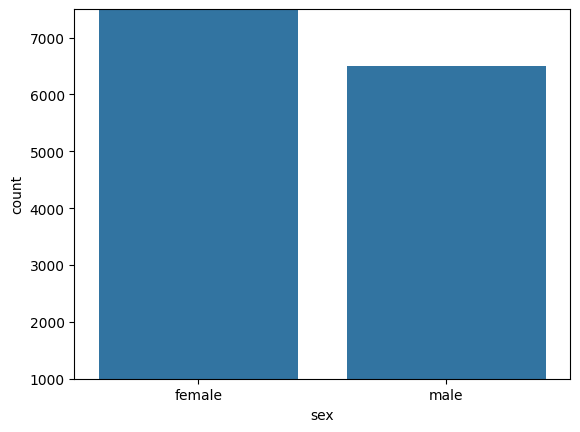

In [24]:
sns.countplot(data = df, x='sex').set(ylim = [1000, 7500])

# 월급 데이터 전처리

In [17]:
df['income'].dtypes

dtype('float64')

In [25]:
df['income'].describe()

count    4534.000000
mean      268.455007
std       198.021206
min         0.000000
25%       150.000000
50%       220.000000
75%       345.750000
max      1892.000000
Name: income, dtype: float64

<Axes: ylabel='Frequency'>

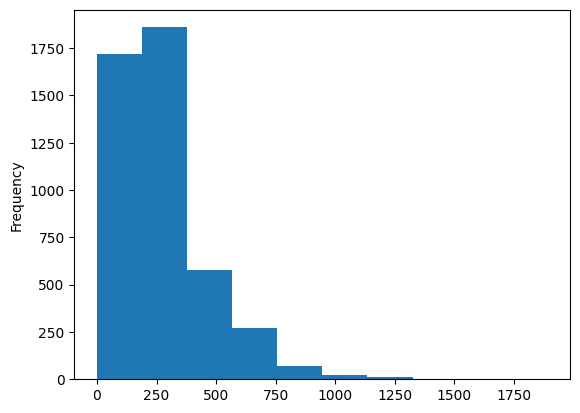

In [26]:
df['income'].plot.hist()

<Axes: xlabel='income', ylabel='Count'>

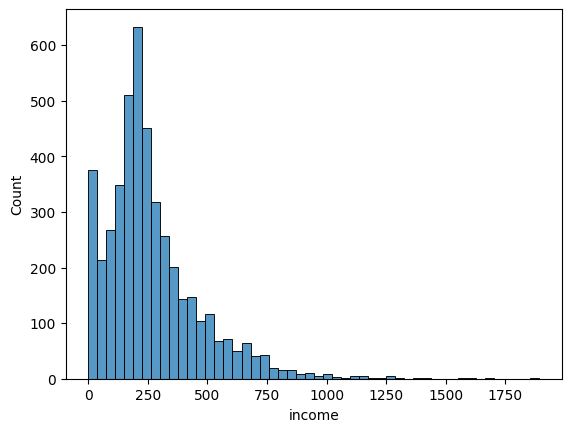

In [27]:
sns.histplot(data = df, x = "income", bins=50)

In [29]:
#결측치 
df['income'].isna().sum()

np.int64(9884)

In [31]:
#이상치 처리
df['income'] = np.where(df['income'] == 9999, np.nan, df['income'])
df['income'].isna().sum()

np.int64(9884)

# 성별에 따른 월급 차이 

In [34]:
# income : 결측치 제거 
# 성별 분리 
# income 평균 구하기
sex_income = df.dropna(subset="income").groupby('sex', as_index=False).agg(mean_income = ("income", "mean"))
sex_income

,sex,mean_income
0,female,186.293096
1,male,349.037571


<Axes: xlabel='sex', ylabel='mean_income'>

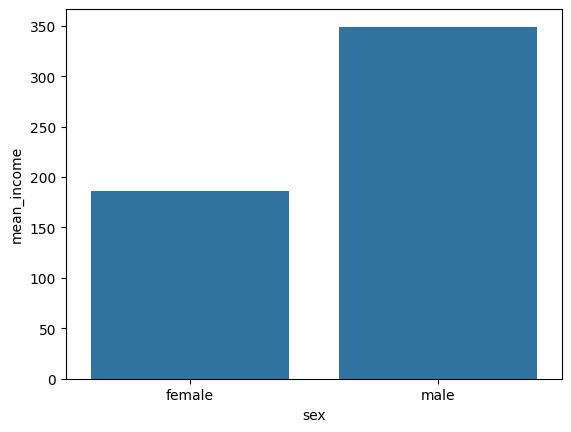

In [35]:
sns.barplot(data=sex_income, x = 'sex', y ='mean_income')

# 나이와 월급의 관계

In [36]:
df['birth'].dtypes 

dtype('float64')

In [37]:
df['birth'].describe()

count    14418.000000
mean      1969.280205
std         24.402250
min       1907.000000
25%       1948.000000
50%       1968.000000
75%       1990.000000
max       2018.000000
Name: birth, dtype: float64

<Axes: xlabel='birth', ylabel='Count'>

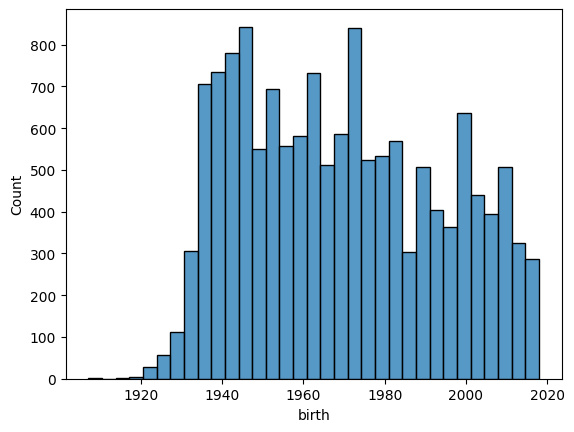

In [39]:
sns.histplot(data = df, x = 'birth')

In [41]:
df['birth'].isna().sum()

np.int64(0)

In [44]:
# 이상치 처리 
df['birth'] = np.where(df['birth'] == 9999, np.nan, df['birth'])
df['birth'].isna().sum()

np.int64(0)

In [46]:
# 출생년도로 나이를 계산 -> 파생변수 추가 
df = df.assign(age = 2019 - df['birth'] + 1)
df['age'].describe() 


count    14418.000000
mean        50.719795
std         24.402250
min          2.000000
25%         30.000000
50%         52.000000
75%         72.000000
max        113.000000
Name: age, dtype: float64

<Axes: xlabel='age', ylabel='Count'>

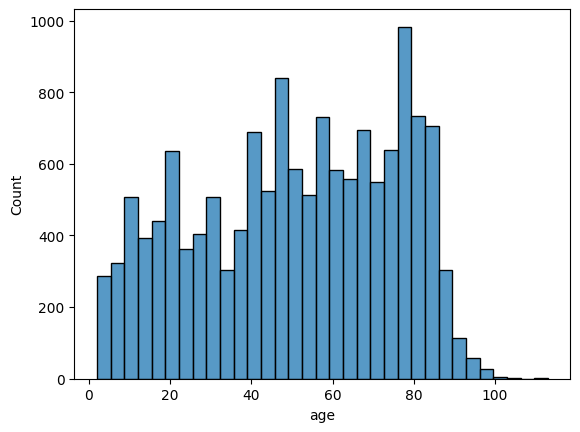

In [48]:
sns.histplot(data = df, x ='age')

In [ ]:
# income: 결측치 제거 
# 나이별 분리
# income 평균 구하기

age_income = df.dropna(subset="income").groupby('age', as_index=False).agg(age_income = ("income", "mean"))
age_income.head()

,age,age_income
0,19.0,162.000000
1,20.0,121.333333
2,21.0,136.400000
3,22.0,123.666667
4,23.0,179.676471


<Axes: xlabel='age', ylabel='age_income'>

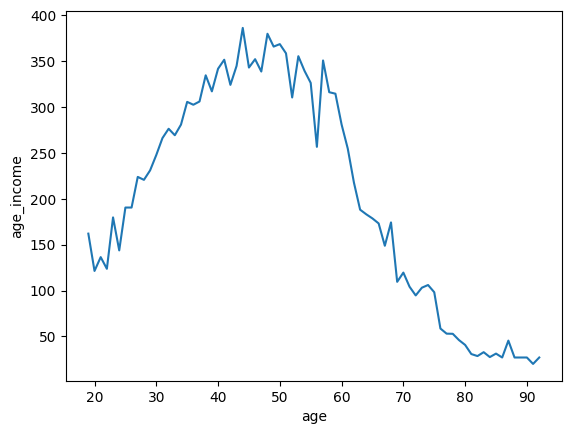

In [52]:
sns.lineplot(data = age_income, x = 'age', y = 'age_income')

# 나이대 별 월급 차이 

In [54]:
df['age'].head()

0    75.0
1    72.0
2    78.0
3    58.0
4    57.0
Name: age, dtype: float64

In [63]:
df['age'] = pd.to_numeric(df['age'], errors='coerce')

In [64]:
# 연령대 별 파생변수 추가

df = df.assign(ageg = np.where(df['age'] < 30, 'young',
                    np.where(df['age'] <= 59, 'middle', 'old')))
df['ageg'].value_counts()

ageg
old    14418
Name: count, dtype: int64

<Axes: xlabel='ageg', ylabel='count'>

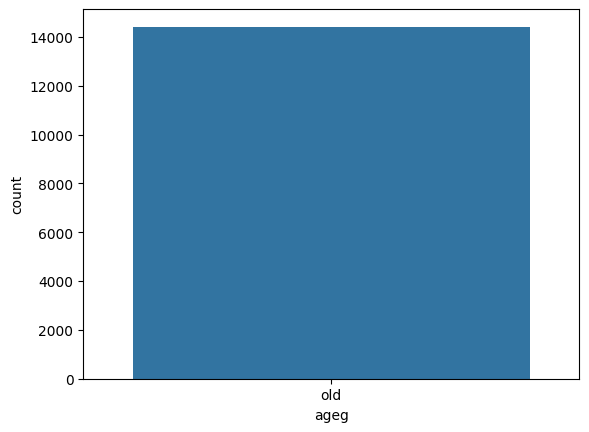

In [66]:
sns.countplot(data = df, x = 'ageg')

In [69]:
# income : 결측치 제거 
# 연령대별 분리 
# income 평균 구하기 
ageg_income = df.dropna(subset="income").groupby('ageg', as_index=False).agg(ageg_income = ("income", "mean"))
ageg_income

,ageg,ageg_income
0,old,268.455007


<Axes: xlabel='ageg', ylabel='ageg_income'>

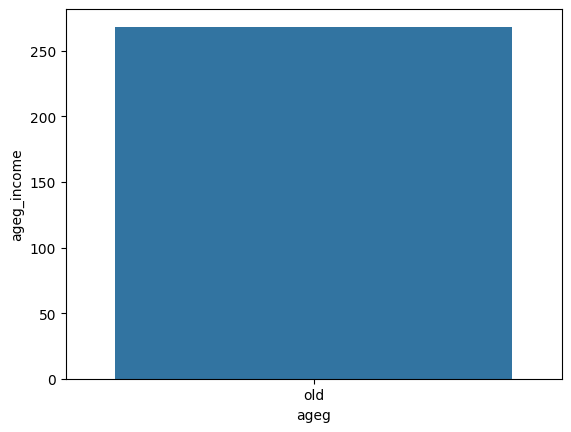

In [71]:
sns.barplot(data = ageg_income, x = 'ageg', y = 'ageg_income')

In [ ]:
sns.barplot(data = ageg_income, x = 'ageg', y = 'ageg_income', order=['young', 'middle', 'old'])

In [78]:
age_sex_income = df.dropna(subset="income").groupby(['age', 'sex'], as_index=False).agg(age_income = ("income", "mean"))
age_sex_income.head()

,age,sex,age_income


# 직업별 월급 차이 

In [74]:
df['code_job'].value_counts()

code_job
611.0     962
941.0     391
521.0     354
312.0     275
873.0     236
         ... 
122.0       2
1009.0      2
861.0       1
423.0       1
872.0       1
Name: count, Length: 150, dtype: int64

In [73]:
list_job = pd.read_excel("./Data/Koweps_Codebook_2019.xlsx", sheet_name="직종코드")
list_job.head()

,code_job,job
0,111,의회 의원∙고위 공무원 및 공공단체 임원
1,112,기업 고위 임원
2,121,행정 및 경영 지원 관리자
3,122,마케팅 및 광고∙홍보 관리자
4,131,연구∙교육 및 법률 관련 관리자


In [80]:
df = df.merge(list_job, how="left", left_on="code_job", right_on="code_job")
df.head()

,h14_id,h14_ind,h14_sn,h14_merkey,h_new,h14_cobf,p14_wsc,p14_wsl,p14_wgc,p14_wgl,...,h14_pers_income1,h14_pers_income2,h14_pers_income3,h14_pers_income4,h14_pers_income5,age,ageg,job_x,job_y,job
0,2.0,1.0,1.0,20101.0,0.0,NaN,0.291589,0.291589,1307.764781,1307.764781,...,NaN,NaN,NaN,0.0,NaN,NaN,old,NaN,NaN,NaN
1,3.0,1.0,1.0,30101.0,0.0,NaN,0.419753,0.419753,1882.570960,1882.570960,...,NaN,NaN,NaN,0.0,NaN,NaN,old,NaN,NaN,NaN
2,4.0,1.0,1.0,40101.0,0.0,NaN,0.265263,0.265980,1189.691668,1192.908537,...,NaN,1284.0,NaN,0.0,NaN,NaN,old,전기공,전기공,전기공
3,6.0,1.0,1.0,60101.0,0.0,NaN,0.494906,0.495941,2219.630833,2224.273816,...,2304.0,NaN,1800.0,0.0,NaN,NaN,old,금속기계 부품 조립원,금속기계 부품 조립원,금속기계 부품 조립원
4,6.0,1.0,1.0,60101.0,0.0,NaN,1.017935,1.017935,4565.389177,4565.389177,...,NaN,NaN,NaN,0.0,NaN,NaN,old,NaN,NaN,NaN


In [81]:
"job" in df.columns

True

In [84]:
df.dropna(subset="code_job")[["code_job", "job"]].head(10)

,code_job,job
2,762.0,전기공
3,855.0,금속기계 부품 조립원
7,941.0,청소원 및 환경미화원
8,999.0,기타 서비스 관련 단순 종사자
14,312.0,경영 관련 사무원
15,254.0,문리∙기술 및 예능 강사
19,510.0,영업 종사자
22,521.0,매장 판매 종사자
23,151.0,판매 및 운송 관리자
24,521.0,매장 판매 종사자


In [87]:
import matplotlib.pyplot as plt 
plt.rcParams.update({"font.family": "Consolas"})

In [88]:
sns.barplot(data = top10, y = "job", x = "job_income")

NameError: name 'top10' is not defined